<a href="https://colab.research.google.com/github/ThiagoDamasz/capacitacao-IA-CS-I/blob/main/Aprendizado_por_Refor%C3%A7o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

## Definindo a função do Grid

Aqui definimos o nosso ambiente. O tamanho da matriz que o robô vai percorrer, as opções de caminho que ele tem e os obstáculos. Além disso também definimos funções para o robô recomeçar o percurso, andar e um caminho visual por onde ele passa.


In [2]:
class GridWorld:
    def __init__(self):
        self.grid_size = 10 #tamanho da matriz
        self.start_pos = (0, 0) # ínicio do robo
        self.goal_pos = (9, 9) # Chegada da matriz
        self.holes_pos = [
            (1, 1), (1, 2), (1, 3),
            (4, 4), (4, 5), (5, 4),
            (7, 8), (8, 7), (8, 8)
        ] #obstáculos
        self.state = self.start_pos

        # Ações: 0=Cima, 1=Baixo, 2=Esquerda, 3=Direita
        self.action_space = [0, 1, 2, 3]

    def reset(self):
        """Reinicia o robô para a posição inicial."""
        self.state = self.start_pos
        return self.state

    def step(self, action):
        """Executa uma ação e retorna: (novo_estado, recompensa, fim)"""
        r, c = self.state # posicao inicial do robô. (r,c/linha,coluna)

        if action == 0:   # Cima subtrai 1 da linha
            r = max(0, r - 1)
        elif action == 1: # Baixo soma 1 da linha
            r = min(self.grid_size - 1, r + 1)
        elif action == 2: # Esquerda subtrai 1 da culuna
            c = max(0, c - 1)
        elif action == 3: # Direita  soma 1 da coluna
            c = min(self.grid_size - 1, c + 1)

        self.state = (r, c)

        # Verificação de Recompensas e Fim de Jogo
        if self.state == self.goal_pos:
            return self.state, 10, True  # Vitória!
        elif self.state in self.holes_pos:
            return self.state, -10, True # Derrota!
        else:
            return self.state, -1, False  # Custo do movimento

    def render(self):
        """Desenha o grid no terminal para visualizarmos o robô."""
        # Cria a matriz limpa preenchida com pontos
        grid = np.full((self.grid_size, self.grid_size), ".")

        # 1. Desenha os buracos/obstáculos um por um nas posições corretas
        for pos in self.holes_pos:
            grid[pos] = "X"

        # 2. Desenha o objetivo (O)
        grid[self.goal_pos] = "O"

        # 3. Desenha o robô (R) por cima de tudo
        grid[self.state] = "R"

        # Imprime no terminal
        for row in grid:
            print(" ".join(row))
        print("-" * 10)

# O cérebro do robô

Abaixo temos a classe QLearningAgent, ela é a representação do cérebro do nosso robô.Em Aprendizado por Reforço, o Agente é a entidade que interage com o ambiente, toma decisões, aprende com as consequências (recompensas ou punições) e tenta descobrir a melhor estratégia possível para resolver o problema.

Como não estamos usando redes neurais, aqui temos um agente tabular. Ou seja uma grande tabela (Q-table) para anotar o quanto vale a pena tomar cada ação em cada quadrado do mapa.

## Os parâmetros

- num_actions

O número de ações possíveis no ambiente.

Está definido como 4 (Cima, Baixo, Esquerda e Direita). Ele serve para sabermos quantas colunas a nossa Q-Table precisará ter.

- alpha

Controla a velocidade com que o robô substitui o conhecimento antigo por informações novas que acabou de vivenciar. Geralmente utiliza-se valores baixos, entre 0.01 e 0.1.

Se o $\alpha$ for muito alto (perto de 1.0): O robô se torna "esquecido". Ele foca apenas na última recompensa recebida e desconsidera todo o histórico do que aprendeu no passado.

Se o $\alpha$ for muito baixo (perto de 0.0): O robô se torna "turrão". Ele demora muito para evoluir porque altera os valores armazenados na tabela de forma extremamente lenta.

- gamma

Define o peso que o robô da para as recompensas futuras em comparação com as recompensas imediatas. Varia entre 0 e 1. Quanto mais próximo de 0, menos "a frente" o robô vai pensar.

Ex:
O robô escolhe sempre um caminho sem penalidades para dar o próximo passo.
Se o gamma estiver mais próximo de 1, o robô analisa não só o próximo passo mas também o final. Isso significa que ele pode escolher o próximo caminho que tem uma penalidade, mas o melhor caminho no final.

- epsilon

A probabilidade inicial de o robô tomar uma decisão de forma 100% aleatória, em vez de consultar a tabela.

Como a Q-Table nasce completamente zerada, o robô não tem nenhuma informação útil guardada. Começar com o epsilon no valor máximo força o agente a explorar o mapa de forma descompromissada (como um "bêbado" andando pelo grid) para mapear onde estão os perigos e os prêmios.


In [3]:
import random

class QLearningAgent:
    def __init__(self, num_states=100, num_actions=4, alpha=0.1, gamma=0.99, epsilon=1.0, max_epsilon=1.0, min_epsilon=0.01, decay_rate=0.005):
        self.num_actions = num_actions
        self.alpha = alpha          # Taxa de aprendizado (o quão rápido ele aceita novas informações)
        self.gamma = gamma          # Fator de desconto (o quanto ele valoriza recompensas futuras)
        self.epsilon = epsilon      # Taxa de exploração inicial
        self.min_epsilon = min_epsilon
        self.decay_rate = decay_rate

        # Inicializa a Q-Table com zeros (100 estados x 4 ações)
        self.q_table = np.zeros((num_states, num_actions))

    def state_to_index(self, state):
        """Converte a coordenada (linha, coluna) em um índice único de 0 a 99."""
        return state[0] * 10 + state[1]

    def choose_action(self, state):
        """Escolhe uma ação usando a estratégia Epsilon-Greedy."""
        state_idx = self.state_to_index(state)

        # Exploração: Escolhe uma ação aleatória
        if random.uniform(0, 1) < self.epsilon:
            return random.choice([0, 1, 2, 3])
        # Explotação: Escolhe a melhor ação da Q-Table para aquele estado
        else:
            return np.argmax(self.q_table[state_idx])

    def update_q_table(self, state, action, reward, next_state):
        """A Equação de Bellman aplicada na prática."""
        state_idx = self.state_to_index(state)
        next_state_idx = self.state_to_index(next_state)

        # Maior valor Q estimado para o próximo estado
        max_future_q = np.max(self.q_table[next_state_idx])

        # Valor Q atual para a ação tomada
        current_q = self.q_table[state_idx, action]

        # Aplicação da fórmula
        new_q = current_q + self.alpha * (reward + self.gamma * max_future_q - current_q)
        self.q_table[state_idx, action] = new_q

    def decay_epsilon(self, episode):
        self.epsilon = self.min_epsilon + (1.0 - self.min_epsilon) * np.exp(-self.decay_rate * episode)



# Treinamento

Aqui colocamos todas as funções que criamos em prática, começando o treinamento do robô.

Também salvamos o desempenho. do treinamentos em listas, para analisarmos depois.

In [4]:
import numpy as np

env = GridWorld()
agent = QLearningAgent()

num_episodes = 800

# Dicionário para traduzir o número da ação em texto explicativo
direcao_acoes = {0: "Cima", 1: "Baixo", 2: "Esquerda", 3: "Direita"}

# Listas para guardar o desempenho
historico_recompensas = []
historico_passos = []

# --- Configuração do Early Stopping (Paciência) ---
meta_recompensa = 8.0      # Média de recompensa que define que o robô aprendeu
patience = 50              # Quantos episódios seguidos ele precisa manter a meta
contador_paciencia = 0     # Contador atual

print("A treinar o robô e a recolher dados de desempenho...\n")

for episode in range(num_episodes):
    state = env.reset()
    done = False

    recompensa_acumulada = 0
    passos_no_episodio = 0

    # Cálculos de progresso do loop principal
    episodio_atual = episode + 1  # Ajustado para começar a mostrar do 1 em vez de 0
    episodios_restantes = num_episodes - episodio_atual

    print(f"--- [Iniciando Episódio {episodio_atual}/{num_episodes}] (Faltam: {episodios_restantes}) ---")
    print(f"Posição Inicial do Robô: {state}")

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.update_q_table(state, action, reward, next_state)

        # Print detalhado de cada ação tomada pelo robô dentro do cenário
        print(f"  -> Passo {passos_no_episodio + 1}: Decisão = Mover para [{direcao_acoes[action]}] | Nova Posição = {next_state} | Recompensa recebida = {reward}")

        recompensa_acumulada += reward
        passos_no_episodio += 1
        state = next_state

    agent.decay_epsilon(episode)

    # Guardar as métricas deste episódio
    historico_recompensas.append(recompensa_acumulada)
    historico_passos.append(passos_no_episodio)

    # Resumo do final do episódio atual
    print(f"--- [Fim do Episódio {episodio_atual}] Passos: {passos_no_episodio} | Recompensa Total: {recompensa_acumulada:.1f}\n")

    # --- Lógica de Parada Antecipada ---
    if episode >= 10:  # Começa a verificar após ter pelo menos 10 episódios históricos
        media_recente = np.mean(historico_recompensas[-10:])

        if media_recente >= meta_recompensa:
            contador_paciencia += 1
        else:
            contador_paciencia = 0  # Reseta se o desempenho cair

        if contador_paciencia >= patience:
            print(f"\n[Early Stopping] O robô convergiu no episódio {episode}!")
            print(f"Média das últimas 10 rodadas: {media_recente:.2f} mantida por {patience} episódios.")
            break

print("Treino concluído!")

Streaming output truncated to the last 5000 lines.
Posição Inicial do Robô: (0, 0)
  -> Passo 1: Decisão = Mover para [Baixo] | Nova Posição = (1, 0) | Recompensa recebida = -1
  -> Passo 2: Decisão = Mover para [Baixo] | Nova Posição = (2, 0) | Recompensa recebida = -1
  -> Passo 3: Decisão = Mover para [Direita] | Nova Posição = (2, 1) | Recompensa recebida = -1
  -> Passo 4: Decisão = Mover para [Direita] | Nova Posição = (2, 2) | Recompensa recebida = -1
  -> Passo 5: Decisão = Mover para [Baixo] | Nova Posição = (3, 2) | Recompensa recebida = -1
  -> Passo 6: Decisão = Mover para [Baixo] | Nova Posição = (4, 2) | Recompensa recebida = -1
  -> Passo 7: Decisão = Mover para [Baixo] | Nova Posição = (5, 2) | Recompensa recebida = -1
  -> Passo 8: Decisão = Mover para [Direita] | Nova Posição = (5, 3) | Recompensa recebida = -1
  -> Passo 9: Decisão = Mover para [Baixo] | Nova Posição = (6, 3) | Recompensa recebida = -1
  -> Passo 10: Decisão = Mover para [Direita] | Nova Posição = (6

# Exemplo Visual do Treinamento

In [5]:
import time

# 1. Instanciar o ambiente
env = GridWorld()
state = env.reset()
done = False
passos = 0

print("Estado Inicial do Grid:")
env.render()
time.sleep(1.5) # Pausa inicial para você observar o mapa

# 2. Loop de execução
while not done:
    passos += 1

    # Escolhe uma ação aleatória (0, 1, 2 ou 3)
    acao = random.choice(env.action_space)

    # Mapeamento apenas para exibir o texto da ação tomada
    nomes_acoes = {0: "CIMA", 1: "BAIXO", 2: "ESQUERDA", 3: "DIREITA"}
    print(f"Passo {passos} | Ação tomada: {nomes_acoes[acao]}")

    # Executa a ação no ambiente
    state, recompensa, done = env.step(acao)

    # Renderiza o estado atualizado na tela
    env.render()

    # Pausa de 0.5 segundos para conseguirmos acompanhar visualmente
    time.sleep(0.5)

# 3. Verificação do resultado
if state == env.goal_pos:
    print(f"🎉 Vitória! O robô chegou ao objetivo 'O' em {passos} passos!")
else:
    print(f"💥 Game Over! O robô caiu em um obstáculo 'X' no passo {passos}.")

Estado Inicial do Grid:
R . . . . . . . . .
. X X X . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . X X . . . .
. . . . X . . . . .
. . . . . . . . . .
. . . . . . . . X .
. . . . . . . X X .
. . . . . . . . . O
----------
Passo 1 | Ação tomada: BAIXO
. . . . . . . . . .
R X X X . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . X X . . . .
. . . . X . . . . .
. . . . . . . . . .
. . . . . . . . X .
. . . . . . . X X .
. . . . . . . . . O
----------
Passo 2 | Ação tomada: CIMA
R . . . . . . . . .
. X X X . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . X X . . . .
. . . . X . . . . .
. . . . . . . . . .
. . . . . . . . X .
. . . . . . . X X .
. . . . . . . . . O
----------
Passo 3 | Ação tomada: ESQUERDA
R . . . . . . . . .
. X X X . . . . . .
. . . . . . . . . .
. . . . . . . . . .
. . . . X X . . . .
. . . . X . . . . .
. . . . . . . . . .
. . . . . . . . X .
. . . . . . . X X .
. . . . . . . . . O
----------
Passo 4 | Ação tomada: BAIXO
. . . . . . . 

# Teste

Nesta fase vamos ver os resultados do treinamento e verificar se foi treinado corretamente. Também veremos se a quantidade de episódios, isso é de vezes que o robô percorreu a matriz, está adequada.

Então treinamos o robô com 2000 episódios, percorrendo uma matriz 10x10 até chegar na última linha da última coluna. Percebemos que pelos gráficos as recompensas geradas aumentam e depois diminuem até se estabilizar.

Isso significa que o robô aprendeu enquanto as recompensas aumentavam, e quando as recompensas se estabilizaram ele já sabia o caminho que deveria percorrer.

2000 Episódios foi muito mais que o necessário para o robô aprender. Pelo gráfico o ideal é de 750 a 900 episódios.

O mesmo vale para a quantidade de passos que o robô deu.

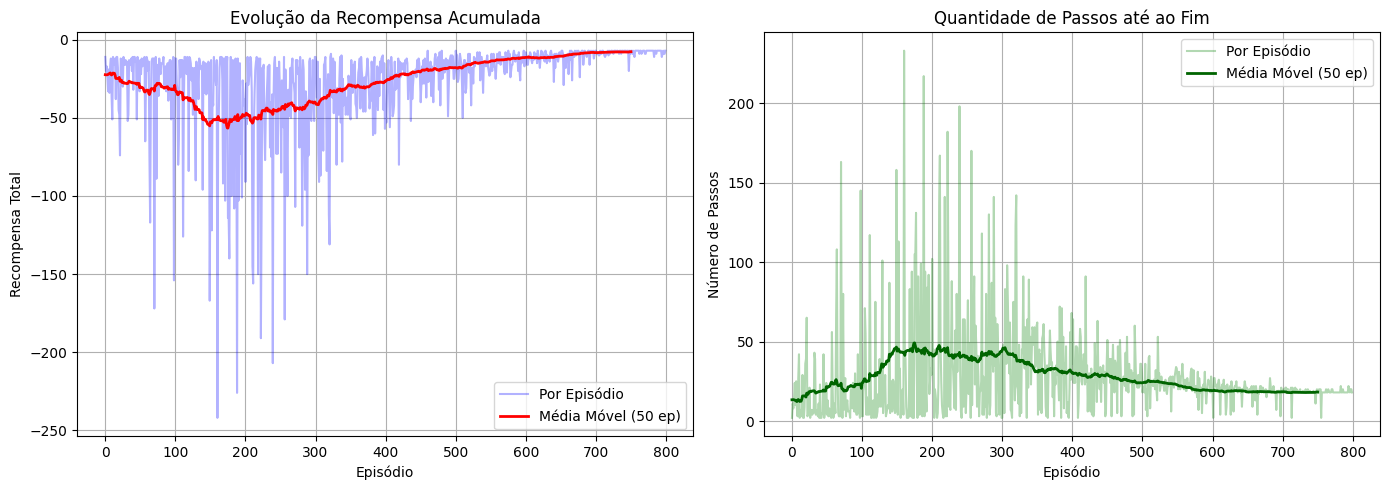

In [ ]:
import matplotlib.pyplot as plt
# 4. PLOTAR OS GRÁFICOS DE DESEMPENHO
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico 1: Recompensas Acumuladas
plt.subplot(1, 2, 1)
plt.plot(historico_recompensas, color='blue', alpha=0.3, label='Por Episódio')
# Linha de média móvel para suavizar o gráfico e ver a tendência clara
medias_moveis_rec = np.convolve(historico_recompensas, np.ones(50)/50, mode='valid')
plt.plot(medias_moveis_rec, color='red', linewidth=2, label='Média Móvel (50 ep)')
plt.title('Evolução da Recompensa Acumulada')
plt.xlabel('Episódio')
plt.ylabel('Recompensa Total')
plt.legend()
plt.grid(True)

# Gráfico 2: Quantidade de Passos
plt.subplot(1, 2, 2)
plt.plot(historico_passos, color='green', alpha=0.3, label='Por Episódio')
medias_moveis_passos = np.convolve(historico_passos, np.ones(50)/50, mode='valid')
plt.plot(medias_moveis_passos, color='darkgreen', linewidth=2, label='Média Móvel (50 ep)')
plt.title('Quantidade de Passos até ao Fim')
plt.xlabel('Episódio')
plt.ylabel('Número de Passos')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Criando uma pequena Rede Neural


## Começando a estrutura

O robô possui 4 ações (cima, baixo, direita, esquerda) então a nossa rede neural precisará ter 4 saídas. Ela também possui 12 neurônios, para mapear os obstáculos.

In [10]:
class TinyRobotQNetwork:
    def __init__(self, n_inputs=4, n_hidden=12, n_outputs=4, lr=0.01, seed=42):
        random.seed(seed)
        self.lr = lr

        # Pesos e vieses da Camada 1 (Entrada -> Oculta)
        self.w1 = [[random.uniform(-0.3, 0.3) for _ in range(n_inputs)] for _ in range(n_hidden)]
        self.b1 = [0.0 for _ in range(n_hidden)]

        # Pesos e vieses da Camada 2 (Oculta -> Saída de 4 Ações)
        self.w2 = [[random.uniform(-0.3, 0.3) for _ in range(n_hidden)] for _ in range(n_outputs)]
        self.b2 = [0.0 for _ in range(n_outputs)]

    def _tanh(self, x):
        return math.tanh(x)

    def forward(self, x):
        # 1. Propagação para a camada oculta
        hidden = []
        for h, weights in enumerate(self.w1):
            z = self.b1[h] + sum(w * xi for w, xi in zip(weights, x))
            hidden.append(self._tanh(z))

        # 2. Propagação para a camada de saída (Valores Q para as 4 ações)
        out = []
        for o, weights in enumerate(self.w2):
            y = self.b2[o] + sum(w * hi for w, hi in zip(weights, hidden))
            out.append(y)

        return hidden, out

    def predict(self, x):
        return self.forward(x)[1]

    def train(self, x, target_q_values):
        """
        Treina a rede usando Backpropagation para aproximar a saída dos target_q_values.
        """
        # 1. Forward pass para obter as ativações atuais
        hidden, out = self.forward(x)

        # 2. Erro da camada de saída (Previsão da Rede - Alvo da Tabela Q)
        out_errors = [out[o] - target_q_values[o] for o in range(len(out))]

        # 3. Erro da camada oculta (Retropropagação do erro multiplicada pela derivada da tanh)
        hidden_errors = []
        for h in range(len(hidden)):
            error_sum = sum(out_errors[o] * self.w2[o][h] for o in range(len(out)))
            dtanh = 1.0 - (hidden[h] ** 2)  # Derivada da tanh: 1 - tanh^2
            hidden_errors.append(error_sum * dtanh)

        # 4. Atualização dos pesos e vieses da Camada 2 (Oculta -> Saída)
        for o in range(len(out)):
            self.b2[o] -= self.lr * out_errors[o]
            for h in range(len(hidden)):
                self.w2[o][h] -= self.lr * out_errors[o] * hidden[h]

        # 5. Atualização dos pesos e vieses da Camada 1 (Entrada -> Oculta)
        for h in range(len(hidden)):
            self.b1[h] -= self.lr * hidden_errors[h]
            for xi_idx, xi in enumerate(x):
                self.w1[h][xi_idx] -= self.lr * hidden_errors[h] * xi

        # Retorna o Erro Quadrático Médio instantâneo para monitorização
        return sum(e**2 for e in out_errors) / len(out_errors)


Na célula abaixo começaos o processo de criação da pequena rede Neural para o Robô. Nessa etapa é a transformação dos dados para eles serem aceitos no modelo.

Como utilizamos uma matriz 10X10, cada posição linha coluna da matriz tem um valor de 1 a 10. Precisamos fazer a normalização desses valores para conseguirmos aplicar o modelo.

O ideal é mater os valores numa escala de -1 a 1.

In [11]:
def robot_features(state, env):
    """
    Converte a coordenada (linha, coluna) do robô em 4 entradas normalizadas
    para a rede neural entre -1 e 1.
    """
    row, col = state
    goal_row, goal_col = env.goal_pos

    # Normaliza as posições atuais (0 a 9 vira -1 a 1)
    norm_row = (row / (env.grid_size - 1)) * 2 - 1
    norm_col = (col / (env.grid_size - 1)) * 2 - 1

    # Calcula a distância até o objetivo e normaliza
    dist_row = (goal_row - row) / (env.grid_size - 1)
    dist_col = (goal_col - col) / (env.grid_size - 1)

    return [norm_row, norm_col, dist_row, dist_col]

In [12]:
# 1. Inicializar a nossa Rede Neural do zero
network = TinyRobotQNetwork(n_inputs=4, n_hidden=12, n_outputs=4, lr=0.01)

epochs = 500  # Número de rodadas completas de ajustes sobre o mapa
print("A iniciar a destilação de conhecimento para a Rede Neural...")

for epoch in range(epochs):
    total_loss = 0.0
    count_states = 0

    # Percorrer todas as combinações possíveis de coordenadas no grid 10x10
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            state = (r, c)

            # Converter a coordenada para o índice da tabela Q antiga
            state_idx = agent.state_to_index(state)

            # Obter os valores alvo da tabela Q clássica (o "gabarito")
            target_q_values = agent.q_table[state_idx]

            # Se a linha estiver completamente zerada (estados nunca visitados),
            # podemos saltar para evitar ensinar ruído à rede
            if np.all(target_q_values == 0.0):
                continue

            # Extrair as 4 características normalizadas para este estado
            features = robot_features(state, env)

            # Treinar a rede neural com este par de (Entrada, Saída Alvo)
            loss = network.train(features, target_q_values)

            total_loss += loss
            count_states += 1

    # Mostrar o progresso a cada 50 épocas
    if (epoch + 1) % 50 == 0 or epoch == 0:
        avg_loss = total_loss / count_states if count_states > 0 else 0
        print(f"Época {epoch+1:03d}/{epochs} | Erro Médio (Loss): {avg_loss:.6f}")

print("\nTreinamento concluído com sucesso! O 'cérebro' matemático da rede foi ajustado.")

A iniciar a destilação de conhecimento para a Rede Neural...
Época 001/500 | Erro Médio (Loss): 9.773590
Época 050/500 | Erro Médio (Loss): 2.479595
Época 100/500 | Erro Médio (Loss): 1.891748
Época 150/500 | Erro Médio (Loss): 1.637209
Época 200/500 | Erro Médio (Loss): 1.485071
Época 250/500 | Erro Médio (Loss): 1.352259
Época 300/500 | Erro Médio (Loss): 1.305110
Época 350/500 | Erro Médio (Loss): 1.283897
Época 400/500 | Erro Médio (Loss): 1.267553
Época 450/500 | Erro Médio (Loss): 1.252065
Época 500/500 | Erro Médio (Loss): 1.238114

Treinamento concluído com sucesso! O 'cérebro' matemático da rede foi ajustado.
